# Business Insights & Strategic Recommendations

## Project:
### Bharat Bazaar Intelligence Platform (BBIP)

---

### Notebook Objective

This notebook transforms analytical findings into meaningful business insights and strategic recommendations.

The analysis focuses on identifying sales trends, profitability, customer behavior, regional performance, and business opportunities. Based on these findings, actionable recommendations are provided to support better decision-making and future business growth.

### Goals

- Analyze overall business performance
- Identify high-performing products and regions
- Evaluate customer purchasing behavior
- Discover business opportunities
- Recommend data-driven strategies
- Present executive-level business conclusions

In [20]:
import os

print(os.getcwd())

c:\Users\Loq\OneDrive\Desktop\Project_6_Bharat_Bazaar_Intelligence_Platform\notebooks


In [21]:
import os

print(os.listdir("../data"))

['cleaned', 'processed', 'raw']


In [22]:
print(os.listdir("../data/cleaned"))

['cleaned_global_ecommerce_sales.csv']


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv("../data/cleaned/cleaned_global_ecommerce_sales.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2000, 15)


,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


# Sales Performance Analysis

## Objective

This section evaluates the overall sales performance of Bharat Bazaar Intelligence Platform.

The analysis helps answer the following business questions:

- What is the total revenue generated?
- How many orders were placed?
- What is the average order value?
- What is the overall business performance?

These Key Performance Indicators (KPIs) provide a high-level overview of the business before diving into detailed analysis.

In [25]:
df.columns.tolist()

['Order_ID',
 'Order_Date',
 'Customer_Name',
 'Customer_Segment',
 'Country',
 'Region',
 'Product_Category',
 'Product_Name',
 'Quantity',
 'Unit_Price',
 'Discount_Percent',
 'Total_Sales',
 'Shipping_Cost',
 'Profit',
 'Payment_Method']

# Key Performance Indicators (KPIs)

Key Performance Indicators (KPIs) provide a quick summary of the business performance.

The following metrics are calculated:

- Total Sales
- Total Profit
- Total Orders
- Average Order Value (AOV)
- Average Profit per Order

These KPIs help stakeholders understand the current business performance before exploring detailed visualizations.

In [26]:
print(df.columns)

Index(['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment',
       'Country', 'Region', 'Product_Category', 'Product_Name', 'Quantity',
       'Unit_Price', 'Discount_Percent', 'Total_Sales', 'Shipping_Cost',
       'Profit', 'Payment_Method'],
      dtype='str')


In [27]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment', 'Country', 'Region', 'Product_Category', 'Product_Name', 'Quantity', 'Unit_Price', 'Discount_Percent', 'Total_Sales', 'Shipping_Cost', 'Profit', 'Payment_Method']


In [28]:
# Business KPIs

total_sales = df["Total_Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
average_order_value = df["Total_Sales"].mean()
average_profit = df["Profit"].mean()

print("=" * 50)
print("BUSINESS PERFORMANCE SUMMARY")
print("=" * 50)

print(f"Total Sales          : ${total_sales:,.2f}")
print(f"Total Profit         : ${total_profit:,.2f}")
print(f"Total Orders         : {total_orders}")
print(f"Average Order Value  : ${average_order_value:,.2f}")
print(f"Average Profit/Order : ${average_profit:,.2f}")

BUSINESS PERFORMANCE SUMMARY
Total Sales          : $484,559.34
Total Profit         : $158,872.32
Total Orders         : 2000
Average Order Value  : $242.28
Average Profit/Order : $79.44


# Sales Distribution Analysis

## Objective

This section analyzes the distribution of total sales across all orders.

Understanding the sales distribution helps identify:

- Average purchasing behavior
- Presence of extremely high or low value orders
- Sales variability
- Business consistency

This analysis is useful for identifying customer spending patterns.

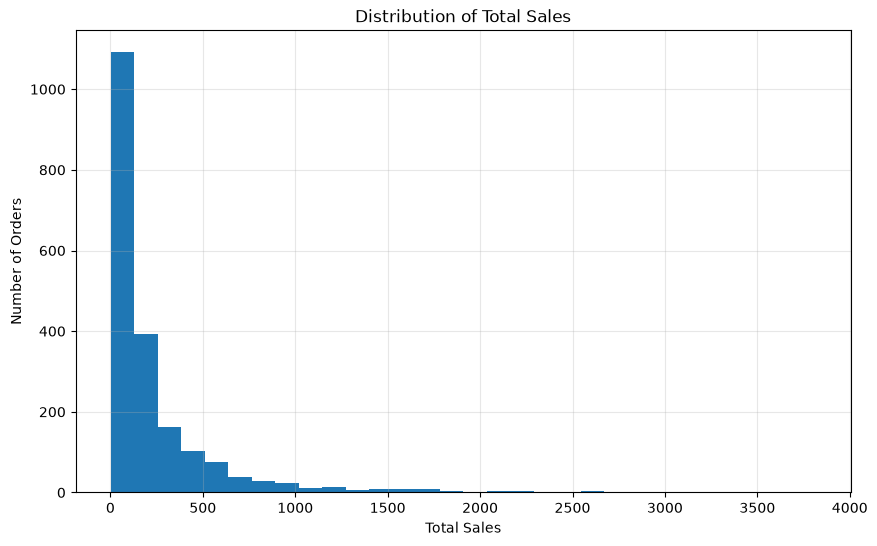

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(df["Total_Sales"], bins=30)

plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Number of Orders")

plt.grid(alpha=0.3)

plt.show()

## Business Insight

The histogram illustrates how customer orders are distributed based on total sales value.

Key observations include:

- Most orders are expected to fall within a specific sales range.
- A small number of orders may contribute significantly higher revenue.
- Such high-value orders can have a strong impact on overall business profitability.

Understanding this distribution helps businesses improve pricing strategies, promotional campaigns, and customer targeting.

# Region-wise Sales Analysis

## Objective

This section analyzes sales performance across different regions.

The analysis helps identify:

- Highest performing regions
- Lowest performing regions
- Revenue contribution by each region

These insights help businesses optimize regional marketing strategies and resource allocation.

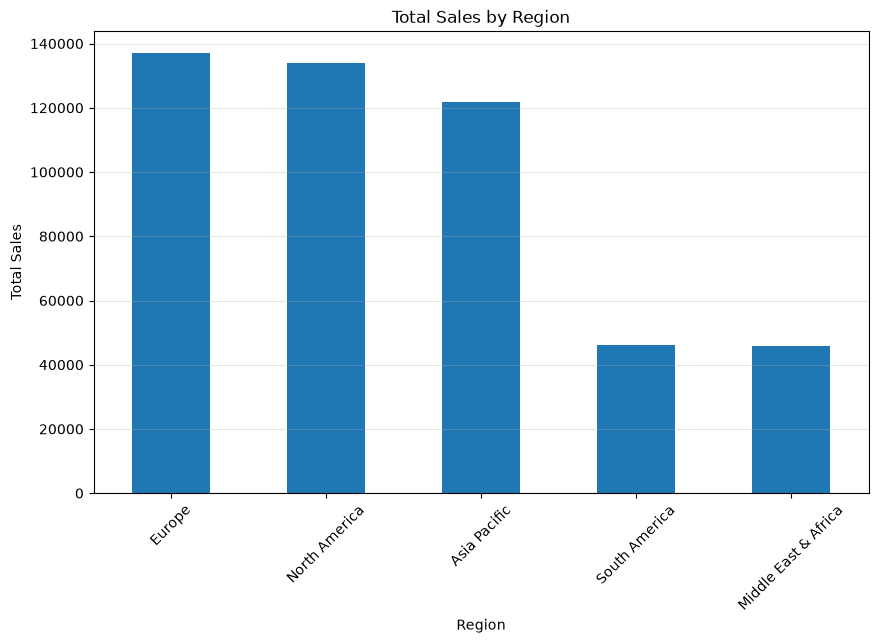

In [30]:
# Region-wise Sales Analysis

region_sales = (
    df.groupby("Region")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.show()

## Business Insight

The regional sales analysis highlights the contribution of each region to overall business revenue.

### Key Findings

- Regions with the highest sales represent strong-performing markets and should continue receiving investment.
- Lower-performing regions may require targeted marketing campaigns, pricing adjustments, or improved customer engagement.
- Regional analysis enables better inventory planning and strategic business expansion.

# Product Category Sales Analysis

## Objective

This section evaluates the sales performance of different product categories.

The analysis helps identify:

- Best-selling product categories
- Categories contributing the highest revenue
- Opportunities for product portfolio optimization

Understanding category performance helps businesses focus on high-performing products and improve low-performing categories.

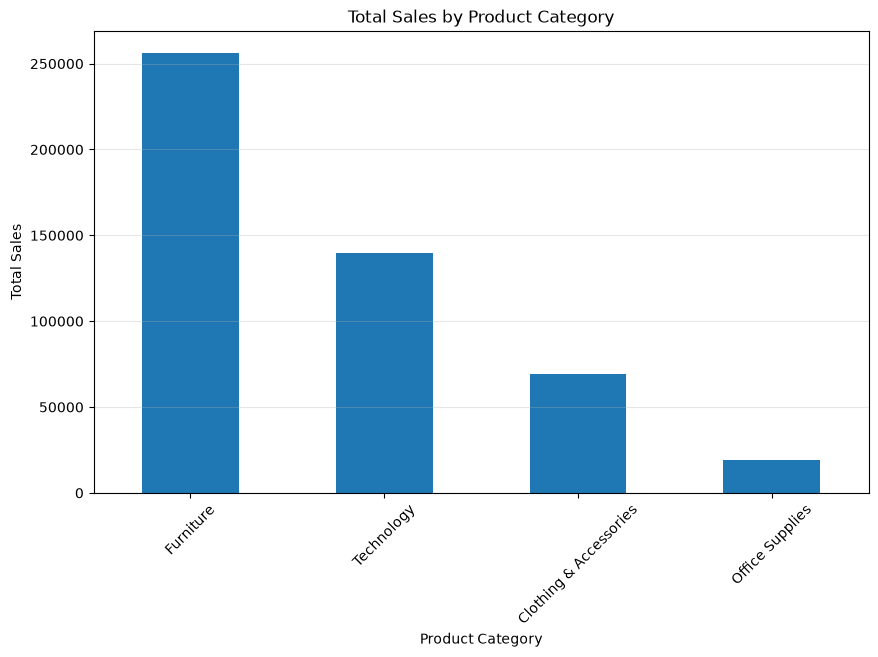

In [31]:
# Product Category Sales Analysis

category_sales = (
    df.groupby("Product_Category")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

category_sales.plot(kind="bar")

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.show()

## Business Insight

The product category analysis identifies which categories generate the highest revenue.

### Key Findings

- High-performing categories should receive continued investment in inventory, marketing, and promotions.
- Low-performing categories should be reviewed for pricing, demand, or product assortment improvements.
- Category-level insights support better inventory planning and strategic product decisions.

# Customer Segment Analysis

## Objective

This section evaluates the sales contribution of different customer segments.

The analysis helps answer:

- Which customer segment generates the highest revenue?
- Which segment should be prioritized for marketing campaigns?
- Which segment has growth opportunities?

Understanding customer segments helps businesses design targeted marketing strategies and improve customer retention.

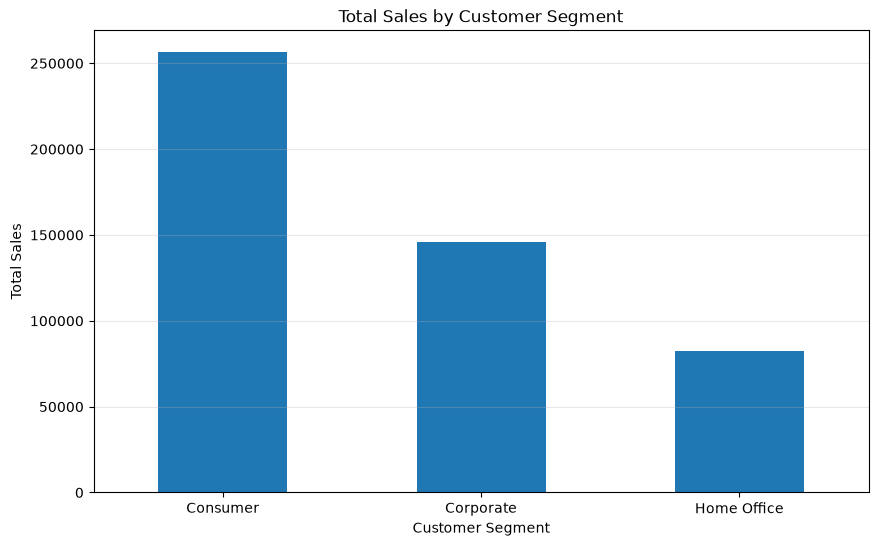

In [32]:
# Customer Segment Analysis

segment_sales = (
    df.groupby("Customer_Segment")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

segment_sales.plot(kind="bar")

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.show()

## Business Insight

The customer segment analysis identifies which customer groups contribute the highest sales.

### Key Findings

- High-value customer segments should receive personalized offers and loyalty rewards.
- Medium-performing segments represent strong growth opportunities through targeted marketing campaigns.
- Lower-performing segments should be analyzed to understand customer needs and improve engagement.

Segment-wise analysis helps businesses increase customer lifetime value and maximize revenue.

# Payment Method Analysis

## Objective

This section analyzes customer payment preferences.

Understanding payment behavior helps businesses:

- Identify the most preferred payment methods.
- Improve payment experience.
- Optimize payment gateway partnerships.

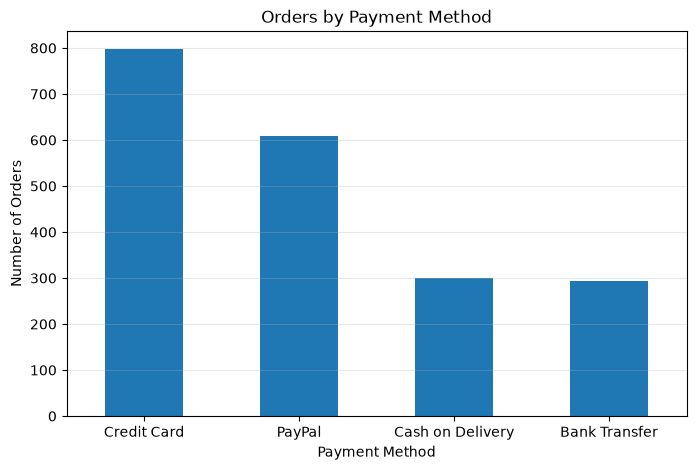

In [33]:
payment_counts = df["Payment_Method"].value_counts()

plt.figure(figsize=(8,5))

payment_counts.plot(kind="bar")

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.show()

## Business Insight

Payment method analysis reveals customer preferences during checkout.

### Key Findings

- The most frequently used payment method reflects customer convenience and trust.
- Businesses should ensure smooth transactions for the most preferred payment options.
- Supporting multiple secure payment methods can improve customer satisfaction and reduce cart abandonment.

# Discount vs Profit Analysis

## Objective

This section examines how discounts influence business profitability.

Understanding this relationship helps answer:

- Do higher discounts reduce profit?
- Is the current discount strategy sustainable?
- Where can pricing be optimized?

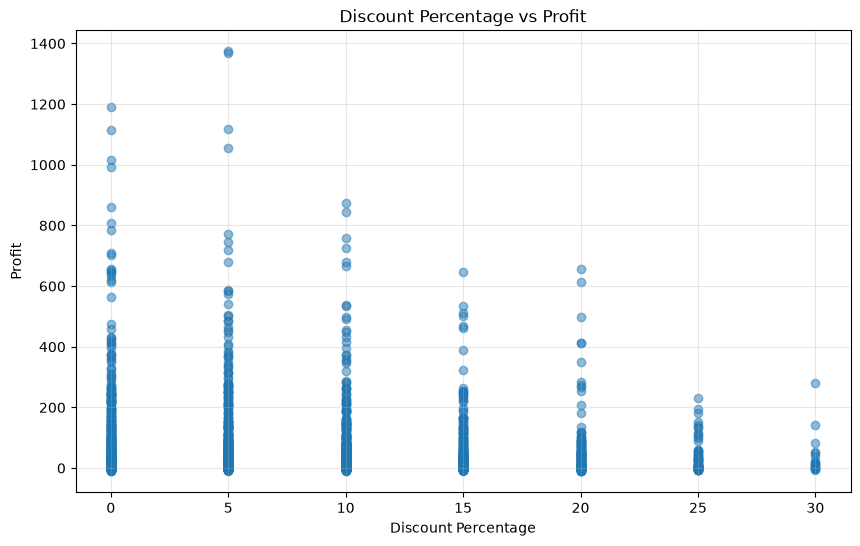

In [34]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Discount_Percent"],
    df["Profit"],
    alpha=0.5
)

plt.title("Discount Percentage vs Profit")
plt.xlabel("Discount Percentage")
plt.ylabel("Profit")

plt.grid(alpha=0.3)

plt.show()

## Business Insight

The scatter plot illustrates the relationship between discount percentage and profit.

### Key Findings

- Higher discounts do not always result in higher profits.
- Extremely large discounts may reduce profit margins.
- Businesses should optimize discount strategies based on customer demand and profitability.

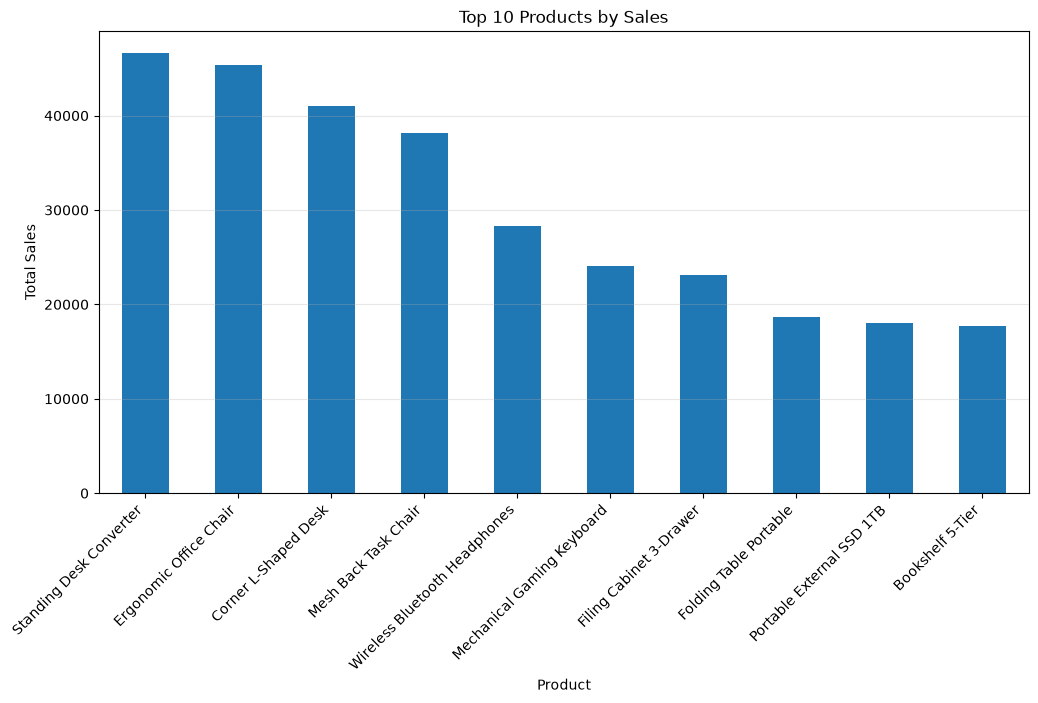

In [35]:
top_products = (
    df.groupby("Product_Name")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.show()

## Business Insight

The analysis identifies the products contributing the highest revenue.

### Key Findings

- High-performing products should receive priority in inventory management.
- Marketing campaigns can leverage these products to increase overall revenue.
- Lower-performing products should be evaluated for pricing, quality, or demand improvements.

# Final Business Recommendations

Based on the complete analysis, the following strategic recommendations are proposed:

1. Increase investment in high-performing regions.
2. Focus marketing efforts on the highest revenue-generating customer segments.
3. Maintain sufficient inventory for top-selling product categories.
4. Optimize discount policies to maximize profitability.
5. Promote the most preferred payment methods to improve customer experience.
6. Continuously monitor sales trends using interactive dashboards.
7. Use predictive analytics for demand forecasting and inventory optimization.

# Conclusion

The Bharat Bazaar Intelligence Platform provides a comprehensive analysis of sales performance, customer behavior, product performance, regional trends, and profitability.

The project demonstrates practical business analytics using Python, SQL, Machine Learning, and data visualization techniques.

Overall, the insights generated can support data-driven decision-making, improve operational efficiency, and enhance business profitability.